
Resumen del Dataset:



,Clase,Cantidad_imagenes,Ancho_promedio,Alto_promedio
0,Early Blight,500,224.0,224.0
1,Fungal Diseases,500,224.0,224.0
2,Healthy,500,224.0,224.0
3,Late Blight,500,224.0,224.0
4,Plant Pests,500,224.0,224.0
5,Potato Cyst Nematode,500,224.0,224.0
6,Potato Virus,500,224.0,224.0



Total de imagenes en el dataset: 3500
Imagenes corruptas detectadas: 0


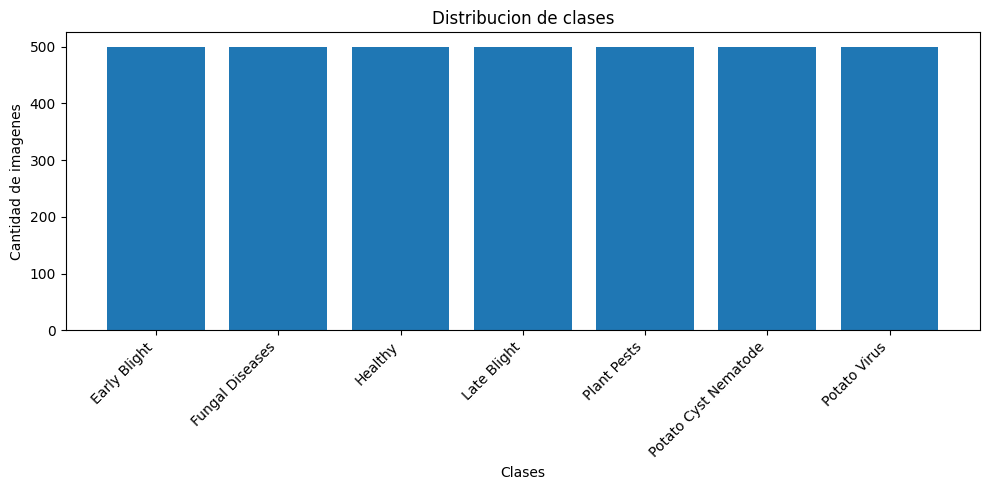

In [4]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Ruta del dataset
DATASET_PATH = r"C:\Users\jaevi\Downloads\Datasets\dataset original\dataset5_shahadhossin"

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".JPG")

data = []
total_global = 0
imagenes_corruptas = []

# Recorrer carpetas
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        total_images = 0
        widths = []
        heights = []

        for file in os.listdir(class_path):
            if file.lower().endswith(VALID_EXTENSIONS):
                img_path = os.path.join(class_path, file)

                try:
                    with Image.open(img_path) as img:
                        width, height = img.size
                        widths.append(width)
                        heights.append(height)
                        total_images += 1
                except Exception:
                    imagenes_corruptas.append(img_path)

        avg_width = sum(widths) / len(widths) if widths else 0
        avg_height = sum(heights) / len(heights) if heights else 0

        total_global += total_images

        data.append({
            "Clase": class_name,
            "Cantidad_imagenes": total_images,
            "Ancho_promedio": round(avg_width, 2),
            "Alto_promedio": round(avg_height, 2)
        })

# DataFrame ordenado
df = pd.DataFrame(data).sort_values(by="Cantidad_imagenes", ascending=False)

print("\nResumen del Dataset:\n")
display(df)

print(f"\nTotal de imagenes en el dataset: {total_global}")
print(f"Imagenes corruptas detectadas: {len(imagenes_corruptas)}")

if imagenes_corruptas:
    print("\nLista de imagenes corruptas:")
    for img in imagenes_corruptas:
        print("-", img)

# Grafico inline en el notebook
plt.figure(figsize=(10, 5))
plt.bar(df["Clase"], df["Cantidad_imagenes"])
plt.xticks(rotation=45, ha="right")
plt.title("Distribucion de clases")
plt.xlabel("Clases")
plt.ylabel("Cantidad de imagenes")
plt.tight_layout()
plt.show()
